# Classificação de Vulnerabilidade Institucional no Sistema Prisional Brasileiro

**Dataset:** SISDEPEN — 18º Ciclo (1º Semestre de 2025)  
**Fonte:** Departamento Penitenciário Nacional (DEPEN) — dados.gov.br  
**Modelos:** Árvore de Decisão, SVM e Rede Neural (MLP)  
**Problema:** Classificação multiclasse supervisionada (baixa / média / alta vulnerabilidade)

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print('Versões das bibliotecas:')
print(f'  pandas:  {pd.__version__}')
print(f'  numpy:   {np.__version__}')

Versões das bibliotecas:
  pandas:  3.0.1
  numpy:   2.4.4


## 2. Carregamento e Exploração do Dataset

O dataset é o SISDEPEN 18º ciclo, com dados de **1.555 estabelecimentos prisionais** brasileiros.
O arquivo está separado por ponto e vírgula (`;`) e codificado em `latin-1` (padrão de arquivos governamentais brasileiros).

In [40]:
df = pd.read_csv(
    '18o-ciclo-base-de-dados-2025-1-semestre.csv',
    sep=';',
    encoding='latin-1',
    low_memory=False
)

# Corrigir encoding dos nomes das colunas e dos valores de texto
df.columns = [c.encode('latin-1').decode('utf-8', errors='replace') for c in df.columns]

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].apply(lambda x: x.encode('latin-1').decode('utf-8', errors='replace') if isinstance(x, str) else x)

print(f'Número de estabelecimentos (linhas): {df.shape[0]}')
print(f'Número de variáveis (colunas):       {df.shape[1]}')

Número de estabelecimentos (linhas): 1555
Número de variáveis (colunas):       1737


### 2.1 Visão geral das colunas de identificação

In [41]:
colunas_id = ['Tipo do Estabelecimento', 'Âmbito', 'UF', 'Situação do Estabelecimento']

for col in colunas_id:
    print(f'--- {col} ---')
    print(df[col].value_counts().to_string())
    print()

--- Tipo do Estabelecimento ---
Tipo do Estabelecimento
Cela física                                1380
Domiciliar sem monitoramento eletrônico     110
Domiciliar com monitoramento eletrônico      65

--- Âmbito ---
Âmbito
Estadual    1550
Federal        5

--- UF ---
UF
MG    220
SP    181
PR    125
RS    112
PE     84
GO     83
RO     75
PB     63
ES     59
MA     56
PA     56
SC     55
RJ     54
MS     52
MT     42
AM     33
CE     33
RN     30
BA     27
TO     27
PI     18
AC     16
AL     13
AP     11
SE     11
DF     10
RR      9

--- Situação do Estabelecimento ---
Situação do Estabelecimento
Ativo    1555



### 2.2 Distribuição por estado

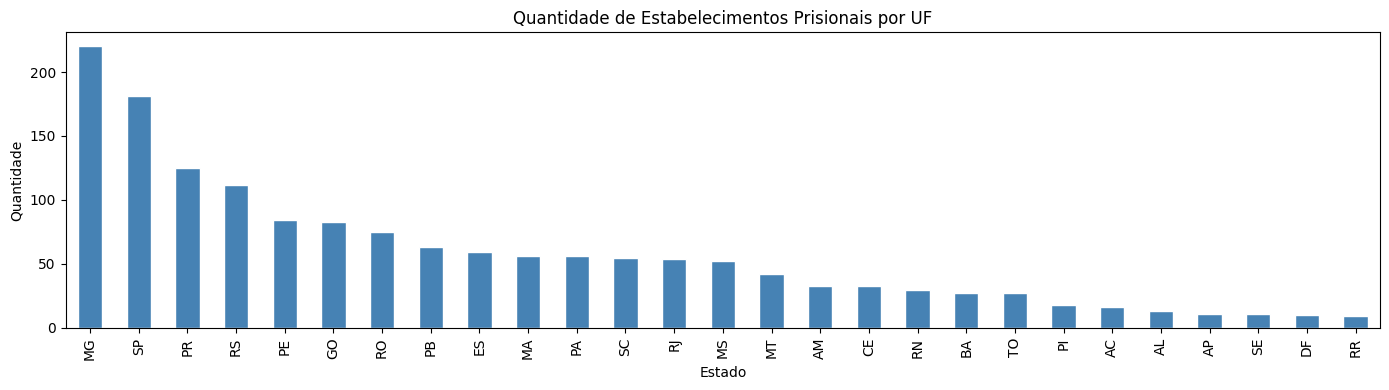

In [42]:
plt.figure(figsize=(14, 4))
df['UF'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Quantidade de Estabelecimentos Prisionais por UF')
plt.xlabel('Estado')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

### 2.3 Filtro: apenas estabelecimentos de cela física

O dataset inclui prisões domiciliares (com e sem monitoramento eletrônico). Esses registros não possuem estrutura física — sem módulo de saúde, sem psicólogo, sem capacidade de vagas — o que distorceria o índice de vulnerabilidade. Por isso mantemos apenas os estabelecimentos de cela física.

In [43]:
print('Distribuição por tipo de estabelecimento:')
print(df['Tipo do Estabelecimento'].value_counts().to_string())
print(f'\nTotal: {len(df)} estabelecimentos')

Distribuição por tipo de estabelecimento:
Tipo do Estabelecimento
Cela física                                1380
Domiciliar sem monitoramento eletrônico     110
Domiciliar com monitoramento eletrônico      65

Total: 1555 estabelecimentos


In [44]:
print(f'Total antes do filtro: {len(df)} estabelecimentos')

df = df[df['Tipo do Estabelecimento'] == 'Cela física'].copy()
df = df.reset_index(drop=True)

print(f'Total após o filtro:   {len(df)} estabelecimentos')
print(f'Removidos:             {1555 - len(df)} prisões domiciliares')

Total antes do filtro: 1555 estabelecimentos
Total após o filtro:   1380 estabelecimentos
Removidos:             175 prisões domiciliares


### 2.4 Valores ausentes nas colunas que serão usadas

Das 1.737 colunas do dataset, utilizaremos apenas as relevantes para construir o índice de vulnerabilidade (y) e as features do modelo (X). Abaixo verificamos a quantidade de valores ausentes nessas colunas para decidir como tratá-los.

In [7]:
colunas_relevantes = {
    # --- Componentes do y (índice de vulnerabilidade) ---
    'cap_total_provisorios':  '1.3 Capacidade do estabelecimento | Presos provisórios | Total',
    'cap_total_fechado':      '1.3 Capacidade do estabelecimento | Regime fechado | Total',
    'cap_total_semiaberto':   '1.3 Capacidade do estabelecimento | Regime semiaberto | Total',
    'cap_total_aberto':       '1.3 Capacidade do estabelecimento | Regime aberto | Total',
    'cap_total_rdd':          '1.3 Capacidade do estabelecimento | Regime Disciplinar Diferenciado (RDD) | Total',
    'cap_total_medida':       '1.3 Capacidade do estabelecimento | Medidas de segurança de internação | Total',
    'pop_total':              '4.1 População prisional | Total',
    'psicologos':             '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Psicólogos | Total',
    'obitos_criminais':       '6.8 Mortalidade no Sistema Prisional (total do período) | Óbitos criminais | Total',
    'obitos_suicidios':       '6.8 Mortalidade no Sistema Prisional (total do período) | Óbitos suicídios | Total',
    'sem_assistencia_jur':    '3.3 Há prestação sistemática de assistência jurídica gratuita às pessoas privadas de liberdade neste estabelecimento? | Sim, por meio da Defensoria Pública',
    'sem_modulo_saude':       '2.4 Módulo de saúde | Não possui módulo de saúde',
    # --- Features do X ---
    'assist_sociais':         '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Assistentes sociais | Total',
    'medicos':                '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Médicos - clínicos gerais | Total',
    'enfermeiros':            '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Enfermeiros | Total',
    'professores':            '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Professores | Total',
    'advogados':              '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Advogados | Total',
    'insp_mp':                '7.5 Foi realizada visita(s) de inspeção no período de referência? | Ministério Público',
    'insp_defensoria':        '7.5 Foi realizada visita(s) de inspeção no período de referência? | Defensoria Pública',
    'insp_judiciario':        '7.5 Foi realizada visita(s) de inspeção no período de referência? | Judiciário',
    'visitantes':             '5.11 Número de pessoas privadas de liberdade que possuem visitantes cadastrados | Pessoas com visitantes cadastrados | Masculino',
    'hiv':                    '6.7 Quantidade de pessoas com agravos transmissíveis na data de fim do período de referência | HIV | Total',
    'tuberculose':            '6.7 Quantidade de pessoas com agravos transmissíveis na data de fim do período de referência | Tuberculose | Total',
    'sifilis':                '6.7 Quantidade de pessoas com agravos transmissíveis na data de fim do período de referência | Sífilis | Total',
    'consultas_medicas':      '6.6 Informações da área de saúde - total do período | Consultas médicas realizadas no estabelecimento | Total',
}

# Verificar valores ausentes apenas nas colunas selecionadas
print(f'{"Variável":<25} {"Ausentes":>10} {"% Ausente":>12}')
print('-' * 50)
for nome, coluna in colunas_relevantes.items():
    ausentes = df[coluna].isna().sum()
    if ausentes > 0:
        pct = ausentes / len(df) * 100
        print(f'{nome:<25} {ausentes:>10} {pct:>11.1f}%')
print('(Variáveis com 0% ausente omitidas)')

Variável                    Ausentes    % Ausente
--------------------------------------------------
cap_total_provisorios             16         1.2%
cap_total_fechado                 10         0.7%
cap_total_semiaberto              25         1.8%
cap_total_aberto                  29         2.1%
cap_total_rdd                     29         2.1%
cap_total_medida                  30         2.2%
psicologos                       134         9.7%
obitos_criminais                  22         1.6%
obitos_suicidios                  22         1.6%
assist_sociais                   123         8.9%
medicos                          121         8.8%
enfermeiros                       82         5.9%
professores                      112         8.1%
advogados                        259        18.8%
visitantes                        24         1.7%
hiv                               12         0.9%
tuberculose                       22         1.6%
sifilis                           17         1.2%

## 3. Tratamento dos Dados

### 3.1 Tratamento de valores ausentes

Após a análise exploratória, identificamos valores ausentes em 19 das 25 colunas selecionadas. Adotamos estratégias diferentes conforme o significado de cada variável:

**Remoção de linhas — colunas de capacidade (1,2% a 2,2% ausentes)**

A capacidade de vagas não pode ser substituída por zero nem por média, pois é usada como denominador no cálculo da taxa de superlotação (`população / capacidade`). Um valor zero resultaria em divisão por infinito, corrompendo o índice. Como representam no máximo 2,2% dos registros, a remoção é preferível à distorção.

**Preenchimento com zero — recursos humanos e indicadores de saúde (0,6% a 18,8% ausentes)**

Para profissionais (psicólogos, médicos, advogados, etc.) e indicadores de saúde (HIV, tuberculose, óbitos), adotamos zero como valor substituto. A justificativa é que o formulário SISDEPEN é preenchido pela própria administração do presídio — estabelecimentos mais precários tendem a ter gestão mais deficiente e, portanto, são mais propensos a não preencher o formulário. Assim, ausência de informação reflete, na maioria dos casos, ausência do próprio recurso.

Vale destacar que os 259 presídios sem advogado registrado (18,8%) são condizentes com a realidade brasileira: a maioria das cadeias públicas não possui advogado próprio no quadro de servidores. A assistência jurídica, quando existe, geralmente vem da Defensoria Pública externamente.

In [ ]:
cr = colunas_relevantes  

cols_capacidade = [
    cr['cap_total_provisorios'], cr['cap_total_fechado'],
    cr['cap_total_semiaberto'],  cr['cap_total_aberto'],
    cr['cap_total_rdd'],         cr['cap_total_medida'],
]
antes = len(df)
df = df.dropna(subset=cols_capacidade, how='all').copy()
df = df.reset_index(drop=True)
print(f'Removidos por capacidade ausente: {antes - len(df)} estabelecimento(s)')

cols_fill_zero = [
    cr['psicologos'],      cr['assist_sociais'],  cr['medicos'],
    cr['enfermeiros'],     cr['professores'],     cr['advogados'],
    cr['obitos_criminais'], cr['obitos_suicidios'],
    cr['hiv'],             cr['tuberculose'],     cr['sifilis'],
    cr['consultas_medicas'],
]
df[cols_fill_zero] = df[cols_fill_zero].fillna(0)
print(f'Preenchimento com zero aplicado em {len(cols_fill_zero)} colunas')
print(f'Estabelecimentos restantes: {len(df)}')

Removidos por capacidade ausente: 0 estabelecimento(s)
Preenchimento com zero aplicado em 12 colunas
Estabelecimentos restantes: 1380


## 4. Construção do Índice de Vulnerabilidade (y)

O índice de vulnerabilidade não existe como coluna no dataset — é calculado a partir de **6 componentes** que medem diferentes dimensões de falha institucional:

**C1 — Taxa de superlotação:** razão entre a população total e a capacidade de vagas.

**C2 — Razão presos/psicólogo:** quanto maior, pior a cobertura. Presídios sem psicólogo usam divisor 0,5 para representar ausência total sem causar divisão por zero.

**C3 — Taxa de mortalidade violenta:** soma de óbitos criminais e suicídios dividida pela população.

**C4 — Taxa de ociosidade:** proporção de presos sem trabalho nem estudo. A soma é limitada pela população para evitar dupla contagem (4,9% dos presídios reportam mais estudantes do que a população total — erro de preenchimento).

**C5 — Ausência de assistência jurídica:** binário. Vale 1 se nenhuma das 4 opções "Sim" do formulário foi marcada.

**C6 — Ausência de módulo de saúde:** binário direto do formulário.

### 4.1 Normalização e cálculo do índice

Os componentes contínuos (C1 a C4) têm escalas muito diferentes e precisam ser normalizados antes de combinar com os binários (C5 e C6). Usamos **Min-Max** em vez de padronização porque os binários já estão em [0, 1] — a padronização produziria valores negativos e sem limite superior, tornando a média inconsistente. O índice final é a **média aritmética** dos 6 componentes, com peso igual a cada dimensão.

### 4.2 Definição das classes

Os limiares são os **percentis 33 e 66** do índice, garantindo distribuição balanceada (~1/3 por classe): baixa vulnerabilidade (0), média (1) e alta (2).

In [9]:
from sklearn.preprocessing import MinMaxScaler

# ── Capacidade total ──────────────────────────────────────────────────────────
df['capacidade_total'] = (
    df[cr['cap_total_provisorios']] +
    df[cr['cap_total_fechado']] +
    df[cr['cap_total_semiaberto']] +
    df[cr['cap_total_aberto']] +
    df[cr['cap_total_rdd']] +
    df[cr['cap_total_medida']]
)

# Remover presídios com capacidade_total = 0 (evita divisão por zero)
antes = len(df)
df = df[df['capacidade_total'] > 0].copy()
df = df.reset_index(drop=True)
print(f'Removidos por capacidade_total = 0: {antes - len(df)} estabelecimento(s)')

pop = df[cr['pop_total']]

# ── Componente 1: Superlotação ────────────────────────────────────────────────
df['c1_superlotacao'] = pop / df['capacidade_total']

# ── Componente 2: Razão presos/psicólogo ─────────────────────────────────────
psic = df[cr['psicologos']].replace(0, 0.5)
df['c2_razao_psicologo'] = pop / psic

# ── Componente 3: Mortalidade violenta ───────────────────────────────────────
df['c3_mortalidade'] = (df[cr['obitos_criminais']] + df[cr['obitos_suicidios']]) / pop.replace(0, 1)

# ── Componente 4: Ociosidade ──────────────────────────────────────────────────
cols_trabalho = [c for c in df.columns if '6.1' in c and '| Total' in c
                 and 'Masculino' not in c and 'Feminino' not in c]

cols_estudo = [
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Alfabetização | Total',
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Ensino Fundamental | Total',
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Ensino Médio | Total',
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Ensino Superior | Total',
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Curso Técnico (acima de 800 horas de aula) | Total',
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Curso de Formação Inicial e Continuada (Capacitação Profissional, acima de 160 horas de aula) | Total',
]

total_trabalho = df[cols_trabalho].fillna(0).sum(axis=1)
total_estudo   = df[cols_estudo].fillna(0).sum(axis=1)
ocupados       = (total_trabalho + total_estudo).clip(upper=pop)
df['c4_ociosidade'] = 1 - (ocupados / pop.replace(0, 1))

# ── Componente 5: Ausência de assistência jurídica ───────────────────────────
cols_sim_jur = [
    '3.3 Há prestação sistemática de assistência jurídica gratuita às pessoas privadas de liberdade neste estabelecimento? | Sim, por meio da Defensoria Pública',
    '3.3 Há prestação sistemática de assistência jurídica gratuita às pessoas privadas de liberdade neste estabelecimento? | Sim, por meio de assistência jurídica privada prestada por advogados conveniados/ dativos',
    '3.3 Há prestação sistemática de assistência jurídica gratuita às pessoas privadas de liberdade neste estabelecimento? | Sim, por meio de assistência jurídica privada prestada por ONG ou outra entidade sem fins lucrativos',
    '3.3 Há prestação sistemática de assistência jurídica gratuita às pessoas privadas de liberdade neste estabelecimento? | Sim, outro. Qual?',
]
tem_assistencia = df[cols_sim_jur].apply(lambda col: col.notna() & (col != 'Não')).any(axis=1)
df['c5_sem_assistencia'] = (~tem_assistencia).astype(int)

# ── Componente 6: Ausência de módulo de saúde ────────────────────────────────
df['c6_sem_saude'] = (df[cr['sem_modulo_saude']] == 'Sim').astype(int)

# ── Normalização Min-Max dos componentes contínuos ───────────────────────────
scaler = MinMaxScaler()
cols_continuas = ['c1_superlotacao', 'c2_razao_psicologo', 'c3_mortalidade', 'c4_ociosidade']
df[cols_continuas] = scaler.fit_transform(df[cols_continuas])

# ── Índice de vulnerabilidade (média dos 6 componentes) ──────────────────────
componentes = ['c1_superlotacao', 'c2_razao_psicologo', 'c3_mortalidade',
               'c4_ociosidade', 'c5_sem_assistencia', 'c6_sem_saude']
df['indice_vulnerabilidade'] = df[componentes].mean(axis=1)

# ── Definição das classes por percentil ──────────────────────────────────────
p33 = df['indice_vulnerabilidade'].quantile(0.33)
p66 = df['indice_vulnerabilidade'].quantile(0.66)

df['y'] = pd.cut(
    df['indice_vulnerabilidade'],
    bins=[-np.inf, p33, p66, np.inf],
    labels=[0, 1, 2]
).astype(int)

print(f'Percentil 33: {p33:.4f}')
print(f'Percentil 66: {p66:.4f}')
print()
contagem = df['y'].value_counts().sort_index()
total = len(df)
for classe, nome in [(0, 'Baixa'), (1, 'Média'), (2, 'Alta')]:
    print(f'  Classe {classe} ({nome}):  {contagem[classe]:4d} presídios  ({contagem[classe]/total*100:.1f}%)')

Removidos por capacidade_total = 0: 44 estabelecimento(s)
Percentil 33: 0.0838
Percentil 66: 0.1670

  Classe 0 (Baixa):   441 presídios  (33.0%)
  Classe 1 (Média):   441 presídios  (33.0%)
  Classe 2 (Alta):   454 presídios  (34.0%)


## 5. Montagem do Dataset para Modelagem

Extraímos 13 features do dataset: quantidade de profissionais de saúde, educação e assistência social; presença de inspeções externas (codificadas como Sim→1, Não→0); visitantes cadastrados; e indicadores de saúde (HIV, tuberculose, sífilis, consultas médicas). Os nulos restantes (~24 em visitantes) são preenchidos com 0, consistente com a estratégia já adotada. As features contínuas (staff e saúde) são **normalizadas por 100 presos** — um presídio com 5 médicos e 50 presos é muito diferente de um com 5 médicos e 5.000 presos; usar contagens brutas mascara essa diferença e prejudica os modelos.

### Padronização dos dados (StandardScaler)

As features possuem escalas muito heterogêneas: o número de visitantes pode chegar a milhares, enquanto o número de médicos ou psicólogos costuma ser inferior a 10. Essa disparidade prejudica qualquer modelo sensível à magnitude das variáveis.

Optamos pela **padronização** (`StandardScaler`: subtrai a média e divide pelo desvio padrão, resultando em média 0 e variância 1) em vez da normalização Min-Max por dois motivos:

1. **Robustez a outliers**: o dataset prisional contém estabelecimentos atípicos (ex.: complexos penitenciários com milhares de internos). O Min-Max comprime todos os valores no intervalo [0, 1] usando o mínimo e o máximo — um único outlier distorce toda a escala. O StandardScaler, por usar média e desvio padrão, é menos sensível a esses extremos.
2. **Requisito do SVM**: o kernel RBF calcula distâncias no espaço de features; sem padronização, features com maior amplitude dominam o cálculo da distância e o modelo ignora as demais.

O scaler é ajustado **apenas no conjunto de treino** (`fit_transform`) e aplicado ao teste (`transform`), evitando vazamento de informação (*data leakage*).

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_names = [
    'assist_sociais', 'medicos', 'enfermeiros', 'professores', 'advogados',
    'insp_mp', 'insp_defensoria', 'insp_judiciario',
    'visitantes', 'hiv', 'tuberculose', 'sifilis', 'consultas_medicas'
]

X_df = pd.DataFrame()

# ── Quantidade de profissionais (contagens brutas) ───────────────────────────
for feat in ['assist_sociais', 'medicos', 'enfermeiros', 'professores', 'advogados']:
    X_df[feat] = df[cr[feat]]

# ── Features binárias de inspeção (0/1) ───────────────────────────────────
for feat in ['insp_mp', 'insp_defensoria', 'insp_judiciario']:
    X_df[feat] = (df[cr[feat]] == 'Sim').astype(int)

# ── Indicadores de saúde (contagens brutas) ───────────────────────────────
for feat in ['visitantes', 'hiv', 'tuberculose', 'sifilis', 'consultas_medicas']:
    X_df[feat] = df[cr[feat]]

# Nulos restantes → 0
X_df = X_df.fillna(0)

X     = X_df.values
y_arr = df['y'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y_arr.shape}')
counts = dict(zip(*np.unique(y_arr, return_counts=True)))
print(f'Classes: {counts}')

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_arr, test_size=0.20, random_state=42, stratify=y_arr
)
print()
print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')

# Padronização (StandardScaler)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled  = scaler_x.transform(X_test)


X shape: (1336, 13)
y shape: (1336,)
Classes: {np.int64(0): np.int64(441), np.int64(1): np.int64(441), np.int64(2): np.int64(454)}

Treino: 1068 | Teste: 268


## 6. Modelo 1 — Árvore de Decisão

Código baseado na **Prática 3 — Minimal Cost-Complexity Pruning**.

Treinamos primeiro a árvore completa (sem poda) para obter Ein/Eout de referência, depois aplicamos **Cost-Complexity Pruning** com validação cruzada via `GridSearchCV(cv=7)` para encontrar o `ccp_alpha` ótimo e plotamos a árvore podada.

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import plot_tree

# Árvore completa (sem poda)
clf_tree = DecisionTreeClassifier(random_state=0)
clf_tree.fit(X_train, y_train)

print('Árvore completa (sem poda):')
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, clf_tree.predict(X_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test,  clf_tree.predict(X_test))))
print(classification_report(y_test, clf_tree.predict(X_test),
                             target_names=['Baixa', 'Média', 'Alta']))

Árvore completa (sem poda):
Ein:  0.0047
Eout: 0.5373
              precision    recall  f1-score   support

       Baixa       0.48      0.44      0.46        89
       Média       0.40      0.45      0.43        88
        Alta       0.52      0.49      0.51        91

    accuracy                           0.46       268
   macro avg       0.47      0.46      0.46       268
weighted avg       0.47      0.46      0.46       268



### Análise do parâmetro alpha — visualizações

Antes de aplicar a poda via `GridSearchCV`, analisamos graficamente como o parâmetro alpha afeta a árvore. São três visualizações:

1. **Alpha vs impureza das folhas**: à medida que alpha cresce, a árvore é podada e a impureza das folhas remanescentes aumenta.
2. **Alpha vs número de nós e profundidade**: mostra como a complexidade da árvore diminui com o aumento de alpha.
3. **Alpha vs acurácia (treino e validação)** — a *boca do jacaré*: para alphas pequenos a árvore memoriza o treino (Ein baixo, Eout alto — boca aberta); conforme alpha cresce, a regularização reduz o overfitting até o ponto ótimo de validação, depois começa a underfit (ambas as curvas caem).

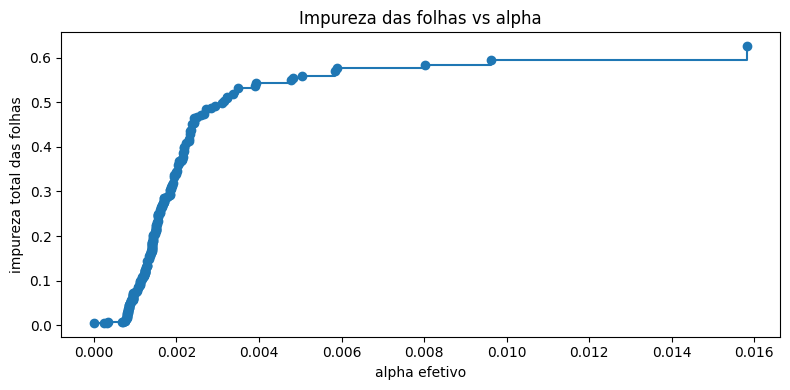

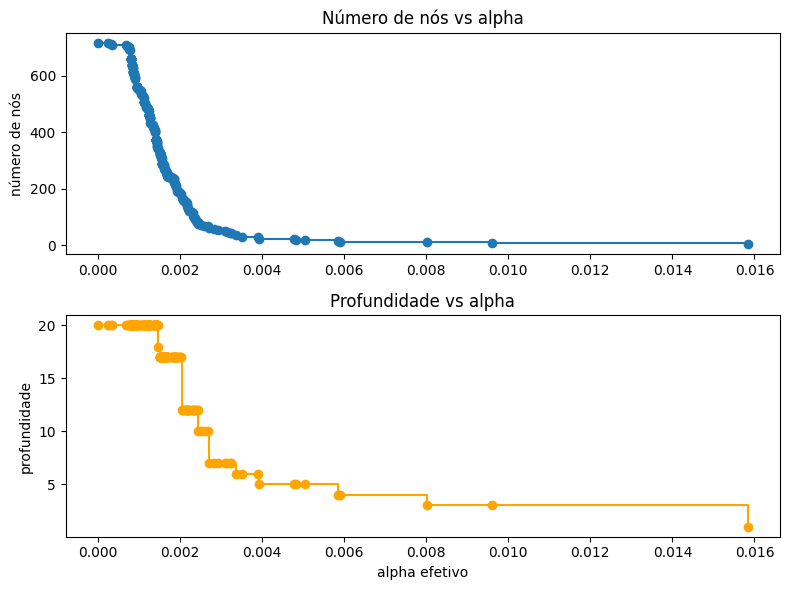

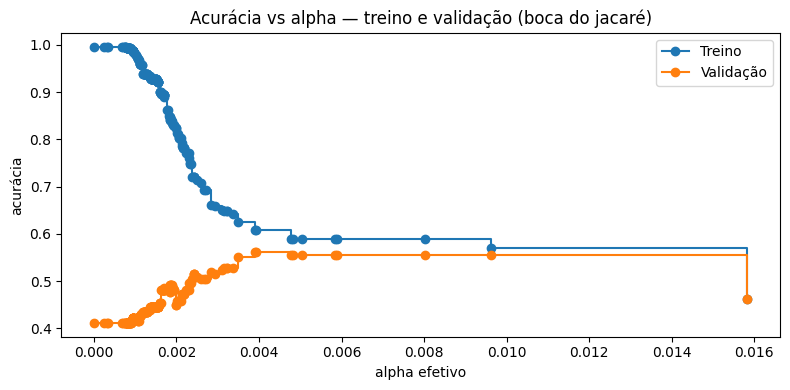

In [12]:
# ── Caminho de poda a partir da árvore completa ─────────────────────────────
path_vis = clf_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas_vis = path_vis.ccp_alphas[:-1]   # descarta o nó raiz trivial
impurities_vis = path_vis.impurities[:-1]

# ── Gráfico 1: alpha vs impureza das folhas ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ccp_alphas_vis, impurities_vis, marker='o', drawstyle='steps-post')
ax.set_xlabel('alpha efetivo')
ax.set_ylabel('impureza total das folhas')
ax.set_title('Impureza das folhas vs alpha')
plt.tight_layout()
plt.show()

# ── Treina uma árvore para cada alpha (para gráficos 2 e 3) ──────────────────
clfs_vis = []
for alpha in ccp_alphas_vis:
    c = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha)
    c.fit(X_train, y_train)
    clfs_vis.append(c)

# ── Gráfico 2: alpha vs número de nós e profundidade ─────────────────────────
node_counts = [c.tree_.node_count for c in clfs_vis]
depths      = [c.tree_.max_depth  for c in clfs_vis]

fig, axes = plt.subplots(2, 1, figsize=(8, 6))
axes[0].plot(ccp_alphas_vis, node_counts, marker='o', drawstyle='steps-post')
axes[0].set_ylabel('número de nós')
axes[0].set_title('Número de nós vs alpha')
axes[1].plot(ccp_alphas_vis, depths, marker='o', drawstyle='steps-post', color='orange')
axes[1].set_xlabel('alpha efetivo')
axes[1].set_ylabel('profundidade')
axes[1].set_title('Profundidade vs alpha')
plt.tight_layout()
plt.show()

# ── Gráfico 3: boca do jacaré — acurácia treino vs validação por alpha ────────
from sklearn.model_selection import train_test_split as tts
X_tr_vis, X_val_vis, y_tr_vis, y_val_vis = tts(
    X_train, y_train, test_size=0.20, random_state=0
)

train_scores, val_scores = [], []
for alpha in ccp_alphas_vis:
    c = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha)
    c.fit(X_tr_vis, y_tr_vis)
    train_scores.append(c.score(X_tr_vis, y_tr_vis))
    val_scores.append(c.score(X_val_vis, y_val_vis))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ccp_alphas_vis, train_scores, marker='o', drawstyle='steps-post', label='Treino')
ax.plot(ccp_alphas_vis, val_scores,   marker='o', drawstyle='steps-post', label='Validação')
ax.set_xlabel('alpha efetivo')
ax.set_ylabel('acurácia')
ax.set_title('Acurácia vs alpha — treino e validação (boca do jacaré)')
ax.legend()
plt.tight_layout()
plt.show()

### Seleção do alpha ótimo via GridSearchCV

Com o comportamento do alpha já visualizado, aplicamos `GridSearchCV` para selecionar automaticamente o valor ótimo usando **cross validation com `cv=5`**.

A justificativa pela dimensão do conjunto de treino é direta: com **N_treino ≈ 1068** amostras, cada fold de validação contém aproximadamente **152 amostras** (1068 ÷ 7), e cada fold de treinamento usa as **916 restantes**. Isso garante que cada submodelo seja treinado com dados suficientes para aprender a estrutura do problema, enquanto o fold de validação tem tamanho representativo para estimar o erro de generalização.

In [55]:
from sklearn.model_selection import GridSearchCV

path = clf_tree.cost_complexity_pruning_path(X_train, y_train)

param_grid = {'ccp_alpha': path.ccp_alphas}

CV_clf_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=param_grid, cv=5, verbose=2, n_jobs=-1
)
CV_clf_tree.fit(X_train, y_train)

best_tree = CV_clf_tree.best_estimator_

print(f'Melhor ccp_alpha: {CV_clf_tree.best_params_["ccp_alpha"]:.6f}')
print(f'Acurácia média CV (validação interna, 5 folds): {CV_clf_tree.best_score_:.4f}')

Fitting 5 folds for each of 201 candidates, totalling 1005 fits
Melhor ccp_alpha: 0.005044
Acurácia média CV (validação interna, 5 folds): 0.5375


In [14]:
# Comportamento no conjunto de treino (Ein)
print('Árvore podada — Ein (treino):')
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, CV_clf_tree.predict(X_train))))
print(classification_report(y_train, CV_clf_tree.predict(X_train),
                             target_names=['Baixa', 'Média', 'Alta']))

Árvore podada — Ein (treino):
Ein:  0.4026
              precision    recall  f1-score   support

       Baixa       0.55      0.61      0.58       352
       Média       0.59      0.48      0.53       353
        Alta       0.66      0.69      0.67       363

    accuracy                           0.60      1068
   macro avg       0.60      0.60      0.59      1068
weighted avg       0.60      0.60      0.60      1068



In [15]:
# Avaliação final no conjunto de teste (Eout)
print('Árvore podada — Eout (teste):')
print('Eout: %0.4f' % (1 - accuracy_score(y_test, CV_clf_tree.predict(X_test))))
print(classification_report(y_test, CV_clf_tree.predict(X_test),
                             target_names=['Baixa', 'Média', 'Alta']))

Árvore podada — Eout (teste):
Eout: 0.4627
              precision    recall  f1-score   support

       Baixa       0.47      0.55      0.51        89
       Média       0.51      0.41      0.45        88
        Alta       0.63      0.65      0.64        91

    accuracy                           0.54       268
   macro avg       0.54      0.54      0.53       268
weighted avg       0.54      0.54      0.54       268



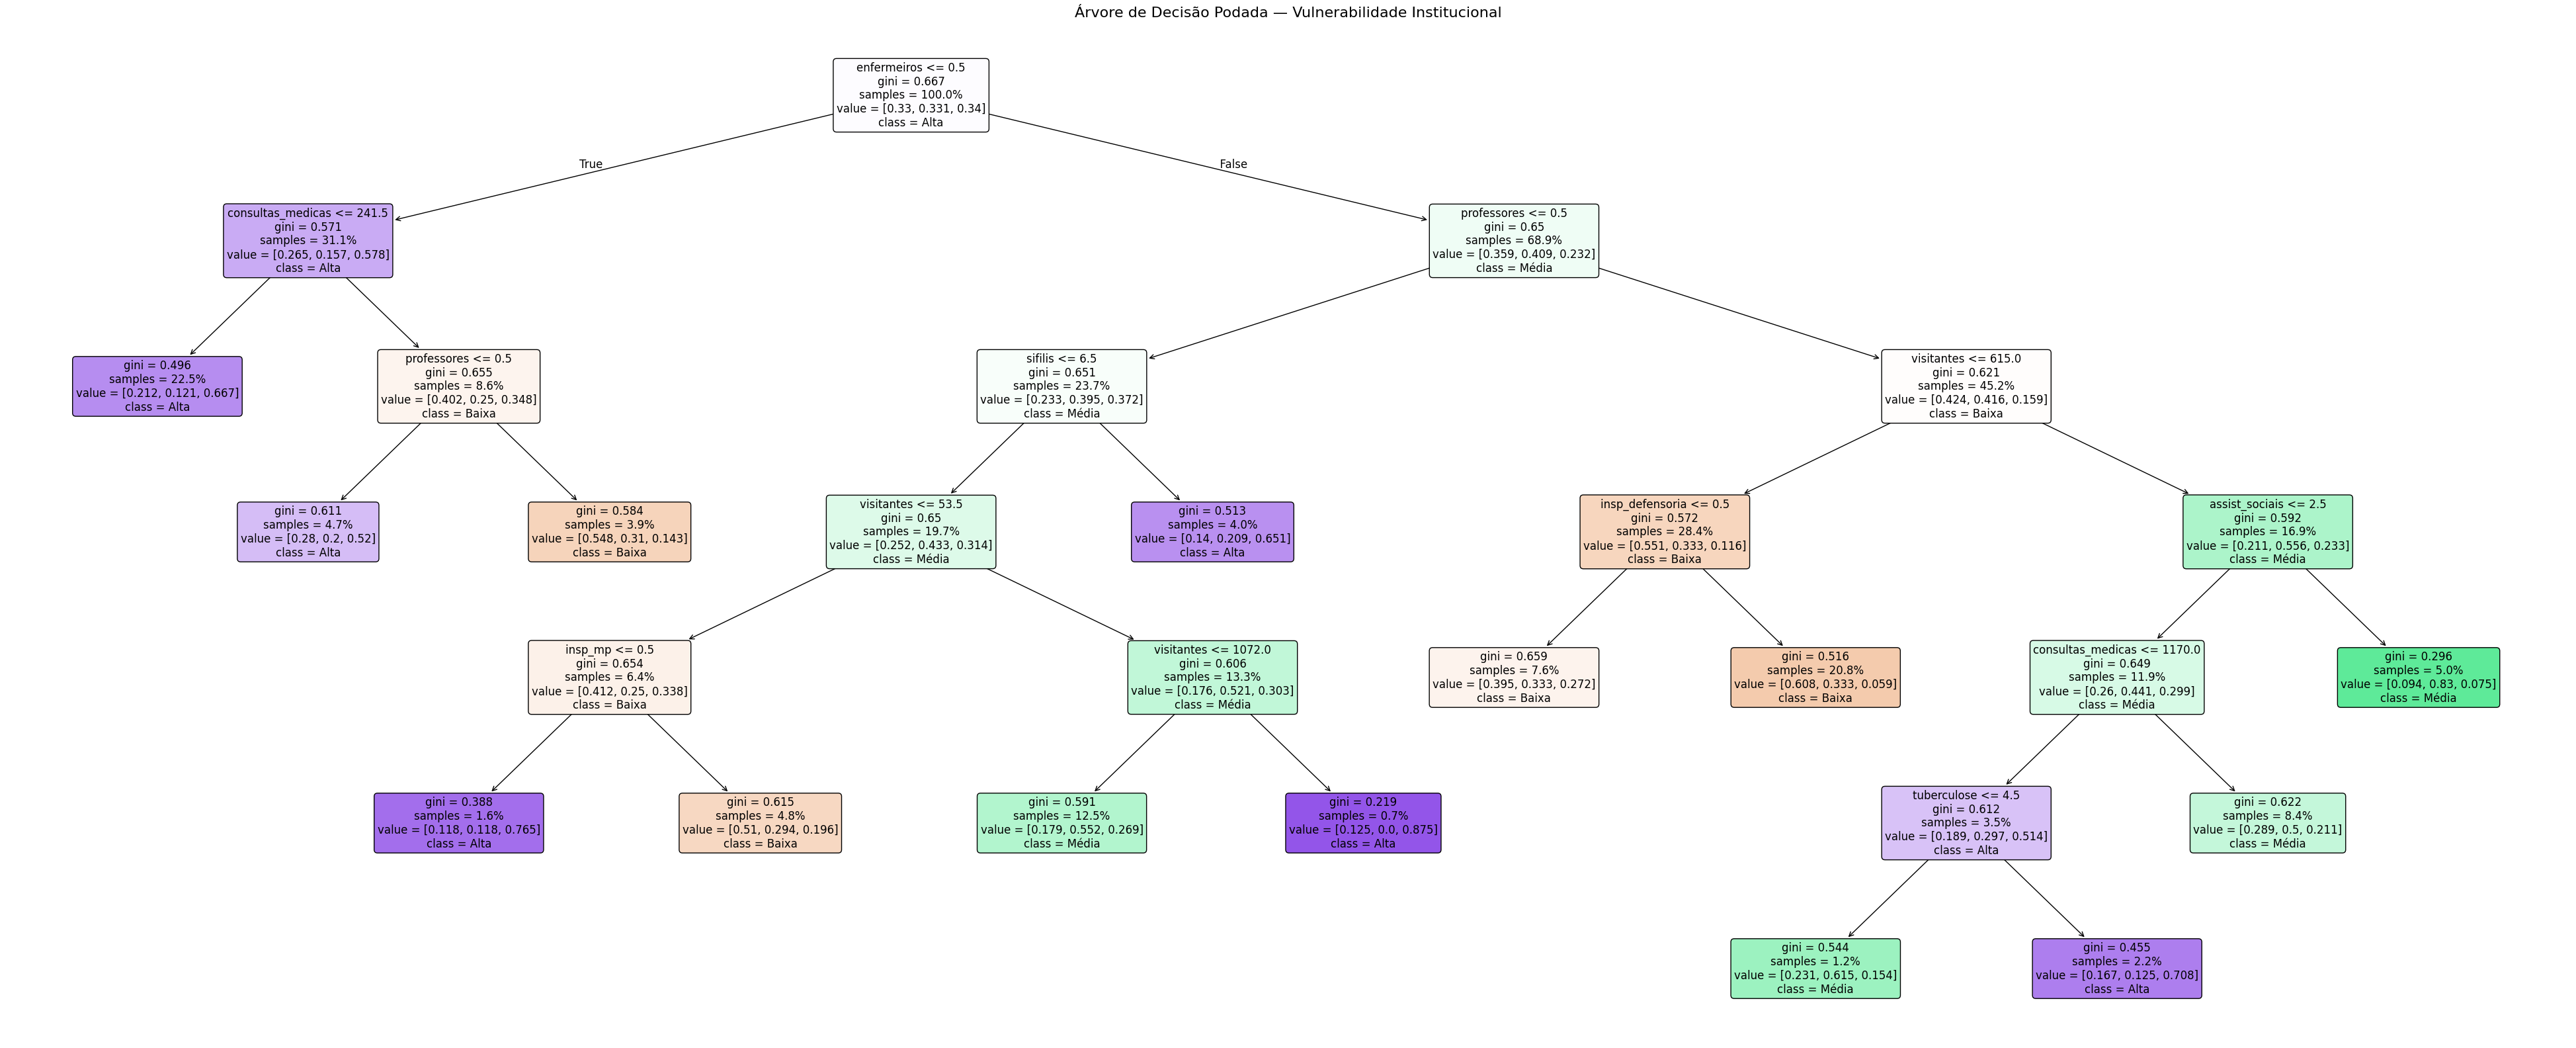

In [16]:
plt.figure(figsize=(50, 20))
plot_tree(
    best_tree,
    feature_names=feature_names,
    class_names=['Baixa', 'Média', 'Alta'],
    filled=True,
    proportion=True,
    fontsize=12,
    rounded=True
)
plt.title('Árvore de Decisão Podada — Vulnerabilidade Institucional', fontsize=16)
plt.show()

## 6.5. Modelo 1b — Random Forest

O Random Forest é um ensemble de árvores de decisão treinadas com subamostras aleatórias dos dados e subconjuntos aleatórios de features (*bagging*). Por combinar múltiplas árvores, tende a superar a árvore individual e a ser mais robusto ao overfitting.

Aplicamos `GridSearchCV(cv=5)` variando `n_estimators`, `max_features` e `max_depth`, seguindo o mesmo padrão da **Prática 4 — Random Forest**.

In [17]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from pprint import pprint

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', 5],
    'max_depth':    [5, 10, 20, None]
}

pprint(param_grid_rf)

cv_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=1
)

%time cv_rf.fit(X_train, y_train)

best_rf = cv_rf.best_estimator_
print()
print(f'Melhor configuração: {cv_rf.best_estimator_}')
print(f'Acurácia média CV (validação interna, 5 folds): {cv_rf.best_score_:.4f}')

{'max_depth': [5, 10, 20, None],
 'max_features': ['sqrt', 'log2', 5],
 'n_estimators': [50, 100, 200]}
Fitting 5 folds for each of 36 candidates, totalling 180 fits


CPU times: total: 328 ms
Wall time: 4.76 s

Melhor configuração: RandomForestClassifier(max_depth=5, random_state=42)
Acurácia média CV (validação interna, 5 folds): 0.5712


In [18]:
# Comportamento no conjunto de treino (Ein)
print('Random Forest — Ein (treino):')
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, best_rf.predict(X_train))))
print(classification_report(y_train, best_rf.predict(X_train),
                             target_names=['Baixa', 'Média', 'Alta']))

Random Forest — Ein (treino):
Ein:  0.3240
              precision    recall  f1-score   support

       Baixa       0.71      0.61      0.65       352
       Média       0.63      0.70      0.66       353
        Alta       0.70      0.72      0.71       363

    accuracy                           0.68      1068
   macro avg       0.68      0.68      0.68      1068
weighted avg       0.68      0.68      0.68      1068



Random Forest — Eout (teste):
Eout: 0.3918
              precision    recall  f1-score   support

       Baixa       0.62      0.54      0.57        89
       Média       0.51      0.59      0.55        88
        Alta       0.72      0.69      0.70        91

    accuracy                           0.61       268
   macro avg       0.61      0.61      0.61       268
weighted avg       0.61      0.61      0.61       268



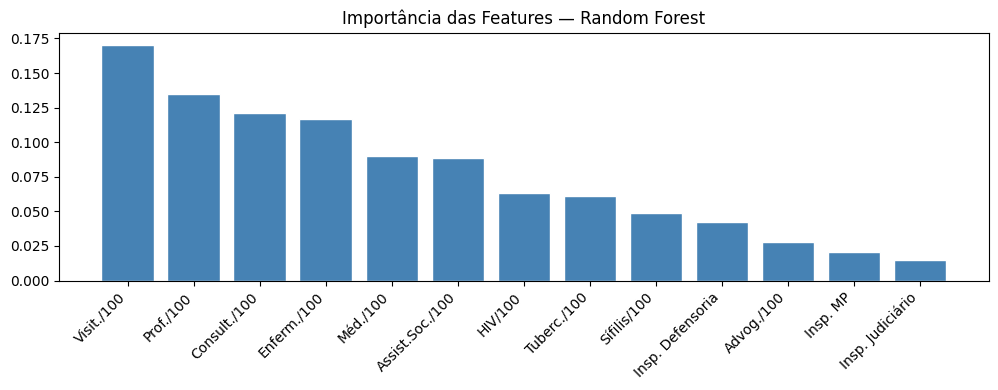

In [19]:
# Avaliação final no conjunto de teste (Eout)
y_pred_rf = best_rf.predict(X_test)

print('Random Forest — Eout (teste):')
print('Eout: %0.4f' % (1 - accuracy_score(y_test, y_pred_rf)))
print(classification_report(y_test, y_pred_rf,
                             target_names=['Baixa', 'Média', 'Alta']))

# Importância das features
importances_rf = best_rf.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]
feature_names_display = [
    'Assist.Soc./100', 'Méd./100', 'Enferm./100', 'Prof./100', 'Advog./100',
    'Insp. MP', 'Insp. Defensoria', 'Insp. Judiciário',
    'Visit./100', 'HIV/100', 'Tuberc./100', 'Sífilis/100', 'Consult./100'
]
plt.figure(figsize=(10, 4))
plt.bar(range(13), importances_rf[indices_rf], color='steelblue', edgecolor='white')
plt.xticks(range(13), [feature_names_display[i] for i in indices_rf], rotation=45, ha='right')
plt.title('Importância das Features — Random Forest')
plt.tight_layout()
plt.show()

## 7. Modelo 2 — SVM (RBF)

Código baseado na **Prática 2 — SVM com Dados Reais**.

Usamos kernel RBF com `GridSearchCV(cv=5)` variando C=[1,5,10,50] e gamma=[0.0001..0.5]. O X de entrada é o `X_scaled` (padronizado), pois o SVM é sensível à escala das features.

### Justificativa do cv=5

 Com **N_treino ≈ 1068** amostras, cada fold de validação contém aproximadamente **214 amostras** (1068 ÷ 5), e cada fold de treinamento usa as **854 restantes**, proporção equivalente a um split interno de 80/20, alinhada com a divisão principal do dataset. Isso garante estimativas de erro estáveis sem custo computacional excessivo para o grid de 32 combinações de hiperparâmetros (4 valores de C × 8 valores de gamma).

In [20]:
from sklearn.svm import SVC

param_grid_svm = {
    'C':     [1, 5, 10, 50],
    'gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
}
grid_svm = GridSearchCV(
    estimator=SVC(kernel='rbf'),
    param_grid=param_grid_svm, cv=5, n_jobs=-1
)

%time grid_svm.fit(X_train_scaled, y_train)
print(f'Melhores parâmetros: {grid_svm.best_params_}')
print(f'Acurácia média CV (validação interna, 5 folds): {grid_svm.best_score_:.4f}')

CPU times: total: 188 ms
Wall time: 1.05 s
Melhores parâmetros: {'C': 10, 'gamma': 0.01}
Acurácia média CV (validação interna, 5 folds): 0.5328


In [21]:
best_svm = grid_svm.best_estimator_
y_pred_svm_train = best_svm.predict(X_train_scaled)

# Comportamento no conjunto de treino (Ein)
print('SVM RBF — Ein (treino):')
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, y_pred_svm_train)))
print(classification_report(y_train, y_pred_svm_train,
                             target_names=['Baixa', 'Média', 'Alta']))

SVM RBF — Ein (treino):
Ein:  0.4026
              precision    recall  f1-score   support

       Baixa       0.61      0.50      0.55       352
       Média       0.59      0.53      0.56       353
        Alta       0.59      0.76      0.66       363

    accuracy                           0.60      1068
   macro avg       0.60      0.60      0.59      1068
weighted avg       0.60      0.60      0.59      1068



In [22]:
y_pred_svm_test = best_svm.predict(X_test_scaled)

# Avaliação final no conjunto de teste (Eout)
print('SVM RBF — Eout (teste):')
print('Eout: %0.4f' % (1 - accuracy_score(y_test, y_pred_svm_test)))
print(classification_report(y_test, y_pred_svm_test,
                             target_names=['Baixa', 'Média', 'Alta']))

print(f'Vetores de suporte por classe: {best_svm.n_support_}')
print(f'Total de SVs: {best_svm.n_support_.sum()}')
print(f'Razão SVs/N_treino: {best_svm.n_support_.sum() / len(X_train):.3f}')

# ── Eout esperado baseado nos vetores de suporte ─────────────────────────────
# Pelo teorema de Leave-One-Out do SVM:
#   E[Eout] <= n_svs / (N_treino - 1)
n_svs    = best_svm.n_support_.sum()
eout_esp = n_svs / (len(X_train) - 1)
print()
print(f'Eout esperado (bound LOO): {eout_esp:.4f}')
print(f'Eout real:                 {1 - accuracy_score(y_test, y_pred_svm_test):.4f}')
print(f'Eout real <= bound LOO: {(1 - accuracy_score(y_test, y_pred_svm_test)) <= eout_esp}')

SVM RBF — Eout (teste):
Eout: 0.3843
              precision    recall  f1-score   support

       Baixa       0.61      0.57      0.59        89
       Média       0.58      0.55      0.56        88
        Alta       0.65      0.73      0.68        91

    accuracy                           0.62       268
   macro avg       0.61      0.61      0.61       268
weighted avg       0.61      0.62      0.61       268

Vetores de suporte por classe: [322 324 269]
Total de SVs: 915
Razão SVs/N_treino: 0.857

Eout esperado (bound LOO): 0.8575
Eout real:                 0.3843
Eout real <= bound LOO: True


## 8. Modelo 3 — Rede Neural (MLP)

Código baseado na **Prática 1 — Classificação com Redes Neurais** (`sol_heart_attack_pred.ipynb`).

### Dimensão VC e Regra de Ouro

A regra de ouro sugere que o número de amostras de treino deve ser pelo menos 10× o número de parâmetros livres. Com **N_treino ≈ 1.068** exemplos, o limite para pesos é:

$$\text{pesos} \leq \frac{N_{treino}}{10} \approx 107$$

A arquitetura **[13 → 6 → 3]** tem:

| Camada | Pesos |
|--------|-------|
| 13 → 6 | 13 × 6 + 6 = **84** |
| 6 → 3  | 6 × 3 + 3 = **21** |
| **Total** | **105 ≤ 107** |

A rede respeita a regra de ouro. Uma única camada oculta é suficiente, o problema tem estrutura linear moderada (13 features numéricas, 3 classes balanceadas) e não exige hierarquia de representações.

### Arquitetura e Compilação

Rede com 2 camadas densas: 13 entradas → 6 neurônios (ReLU) → 3 saídas (Softmax). Como `y` é inteiro (0, 1, 2), usamos `sparse_categorical_crossentropy` em vez de `categorical_crossentropy`.

### Justificativa do batch size e número de épocas

**Batch size = 16**

Seguimos o mesmo valor da Prática 1 (`sol_heart_attack_pred.ipynb`). Com N_treino ≈ 1.068 amostras, um batch de 16 exemplos gera aproximadamente **67 atualizações de gradiente por época**, o que é suficiente para convergência estável. Batches menores introduzem ruído no gradiente que atua como regularizador implícito, reduzindo a tendência de memorização. Batches maiores convergem mais rápido mas tendem ao overfitting em datasets pequenos.

**Épocas = 100**

100 épocas permitem que a rede atinja convergência sem custo computacional excessivo. A escolha é validada pelas curvas de aprendizado: se a loss de validação estabilizar antes da época 100, o modelo convergiu; se começar a subir, há overfitting. O K-Fold a seguir confirma a estabilidade do aprendizado ao longo das 100 épocas.

In [23]:
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn import model_selection

BATCH_SIZE   = 16
RANDOM_STATE = 42

# Arquitetura [13 → 6 → 3]
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(1000, kernel_initializer='he_normal',     activation='relu'))
model.add(Dense(1000, kernel_initializer='he_normal',     activation='relu'))
model.add(Dense(1000, kernel_initializer='glorot_normal', activation='softmax'))


initial_weights = model.get_weights()

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │        14,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     1,001,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,016,000 (7.69 MB)

 Trainable params: 2,016,000 (7.69 MB)

 Non-trainable params: 0 (0.00 B)

None


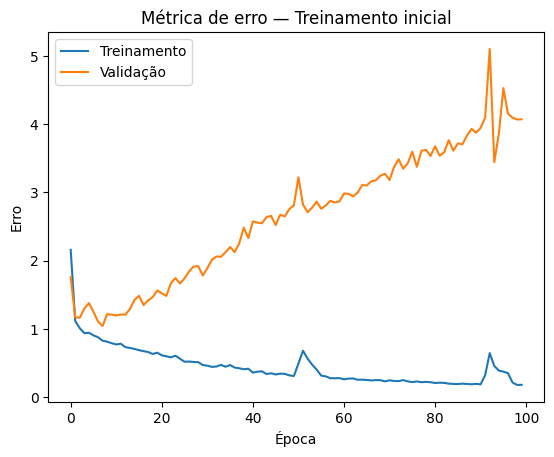

--> Acurácia (treino):    0.9473
--> Acurácia (validação): 0.4720
--> E_val - E_in = 3.9204


In [24]:
X_train_nn, X_val_nn, y_train_nn, y_val_nn = model_selection.train_test_split(
    X_train_scaled, y_train, random_state=RANDOM_STATE, test_size=0.2
)

model.set_weights(initial_weights)
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100, batch_size=BATCH_SIZE, verbose=0
)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Métrica de erro — Treinamento inicial')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Validação'])
plt.show()

E_in,  acc_train_nn = model.evaluate(X_train_nn, y_train_nn, verbose=0)
E_val, acc_val_nn   = model.evaluate(X_val_nn,   y_val_nn,   verbose=0)

print(f'--> Acurácia (treino):    {acc_train_nn:.4f}')
print(f'--> Acurácia (validação): {acc_val_nn:.4f}')
print(f'--> E_val - E_in = {E_val - E_in:.4f}')

### Análise de overfitting

O gráfico acima mostra **overfitting intencional**: a arquitetura foi deliberadamente superdimensionada para confirmar que a rede consegue memorizar os dados de treino (acurácia de treino alta, "boca do jacaré" pronunciada). Esse é o ponto de partida recomendado — provar que o modelo tem capacidade suficiente antes de regularizar.

O próximo passo é reduzir o overfitting sem perder desempenho de generalização.

### Regularização — Passo 1: L2 + EarlyStopping

Adicionamos **regularização L2** (`kernel_regularizer=l2(λ)`) em cada camada densa: penaliza pesos grandes, forçando representações mais simples. O **EarlyStopping** interrompe o treino quando a `val_loss` para de melhorar por `patience` épocas e restaura os pesos do melhor momento.

Parou na epoca 65 de 100


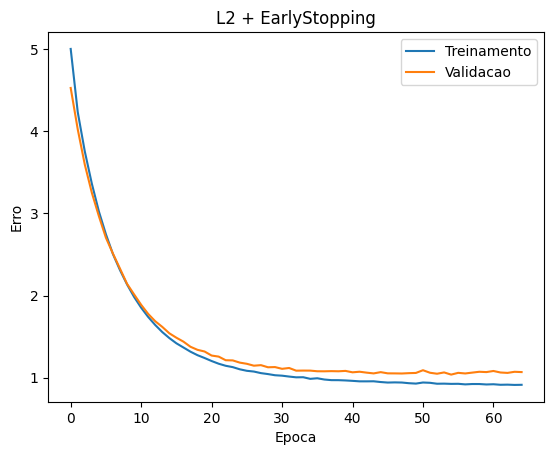

--> Acuracia (treino):    0.6276
--> Acuracia (validacao): 0.5561
--> E_val - E_in = 0.1312


In [25]:
from keras import regularizers
from keras.callbacks import EarlyStopping

model_l2 = Sequential()
model_l2.add(Input(shape=(13,)))
model_l2.add(Dense(100, kernel_initializer='he_normal',
                   kernel_regularizer=regularizers.l2(0.01), activation='relu'))
model_l2.add(Dense(100, kernel_initializer='he_normal',
                   kernel_regularizer=regularizers.l2(0.01), activation='relu'))
model_l2.add(Dense(3, kernel_initializer='glorot_normal', activation='softmax'))
model_l2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

history_l2 = model_l2.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100, batch_size=BATCH_SIZE,
    callbacks=[es], verbose=0
)

print(f'Parou na epoca {len(history_l2.history["loss"])} de 100')

plt.plot(history_l2.history['loss'])
plt.plot(history_l2.history['val_loss'])
plt.title('L2 + EarlyStopping')
plt.ylabel('Erro'); plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

E_in_l2,  acc_tr_l2 = model_l2.evaluate(X_train_nn, y_train_nn, verbose=0)
E_val_l2, acc_vl_l2 = model_l2.evaluate(X_val_nn,   y_val_nn,   verbose=0)
print(f'--> Acuracia (treino):    {acc_tr_l2:.4f}')
print(f'--> Acuracia (validacao): {acc_vl_l2:.4f}')
print(f'--> E_val - E_in = {E_val_l2 - E_in_l2:.4f}')


### Regularizacao — Passo 2: Grid Search de hiperparametros

Busca sistematica sobre `neurons`, `l2_reg` e `dropout` com 5-fold estratificado — mesmo procedimento do professor na Pratica 1. A combinacao com maior acuracia media de validacao define a arquitetura final.

In [26]:
from sklearn.model_selection import StratifiedKFold
from itertools import product
from keras.layers import Dropout

param_grid = {
    'neurons': [50, 100],
    'l2_reg':  [0.01, 0.1],
    'dropout': [0.0, 0.2],
}

combinacoes = list(product(*param_grid.values()))
param_names = list(param_grid.keys())
skf_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_gs = []

for combo in combinacoes:
    params = dict(zip(param_names, combo))
    accs_val = []

    for tr_idx, vl_idx in skf_gs.split(X_train_scaled, y_train):
        Xtr, Xvl = X_train_scaled[tr_idx], X_train_scaled[vl_idx]
        ytr, yvl = y_train[tr_idx],         y_train[vl_idx]

        m = Sequential()
        m.add(Input(shape=(13,)))
        m.add(Dense(params['neurons'], kernel_initializer='he_normal',
                    kernel_regularizer=regularizers.l2(params['l2_reg']),
                    activation='relu'))
        if params['dropout'] > 0:
            m.add(Dropout(params['dropout']))
        m.add(Dense(params['neurons'], kernel_initializer='he_normal',
                    kernel_regularizer=regularizers.l2(params['l2_reg']),
                    activation='relu'))
        if params['dropout'] > 0:
            m.add(Dropout(params['dropout']))
        m.add(Dense(3, kernel_initializer='glorot_normal', activation='softmax'))
        m.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

        es_gs = EarlyStopping(monitor='val_loss', patience=10,
                              restore_best_weights=True, verbose=0)
        m.fit(Xtr, ytr, validation_data=(Xvl, yvl),
              epochs=100, batch_size=BATCH_SIZE, callbacks=[es_gs], verbose=0)

        _, acc = m.evaluate(Xvl, yvl, verbose=0)
        accs_val.append(acc)

    media = np.mean(accs_val)
    resultados_gs.append((media, params))
    print(f'neurons={params["neurons"]:3d} | l2={params["l2_reg"]} | dropout={params["dropout"]} | val_acc={media:.4f}')

resultados_gs.sort(key=lambda x: x[0], reverse=True)
best_acc_gs, best_params_gs = resultados_gs[0]
print(f'Melhores parametros: {best_params_gs}  (val_acc={best_acc_gs:.4f})')


neurons= 50 | l2=0.01 | dropout=0.0 | val_acc=0.5300


neurons= 50 | l2=0.01 | dropout=0.2 | val_acc=0.5393


neurons= 50 | l2=0.1 | dropout=0.0 | val_acc=0.5300


neurons= 50 | l2=0.1 | dropout=0.2 | val_acc=0.4850


neurons=100 | l2=0.01 | dropout=0.0 | val_acc=0.5318


neurons=100 | l2=0.01 | dropout=0.2 | val_acc=0.5449


neurons=100 | l2=0.1 | dropout=0.0 | val_acc=0.5309


neurons=100 | l2=0.1 | dropout=0.2 | val_acc=0.4972
Melhores parametros: {'neurons': 100, 'l2_reg': 0.01, 'dropout': 0.2}  (val_acc=0.5449)


### K-Fold com a arquitetura regularizada

Aplicamos os melhores hiperparametros encontrados no grid search ao K-Fold completo para estimar Ein e Eval medios e confirmar estabilidade.

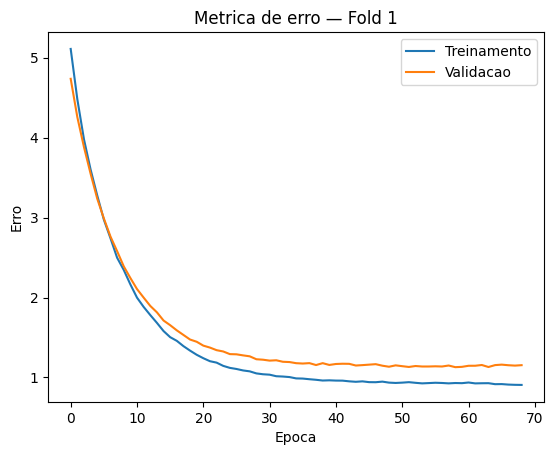

--> Acuracia (treino):    0.6159
--> Acuracia (validacao): 0.5140
--> E_val - E_in = 0.2343



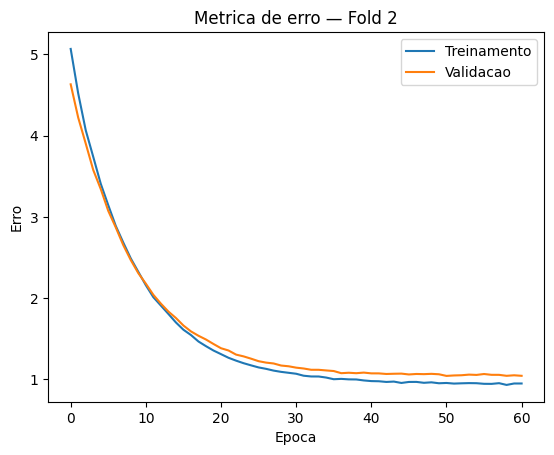

--> Acuracia (treino):    0.6030
--> Acuracia (validacao): 0.5374
--> E_val - E_in = 0.1133



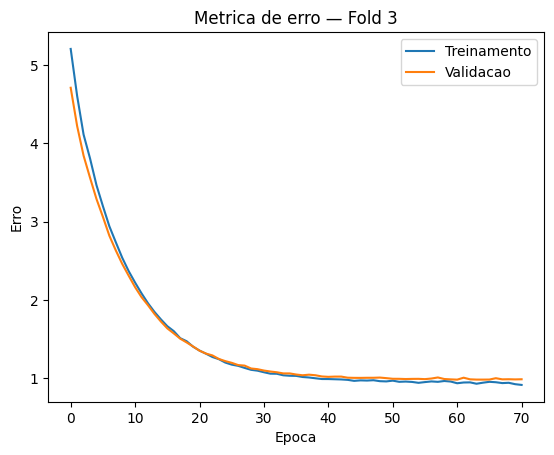

--> Acuracia (treino):    0.6218
--> Acuracia (validacao): 0.5607
--> E_val - E_in = 0.0691



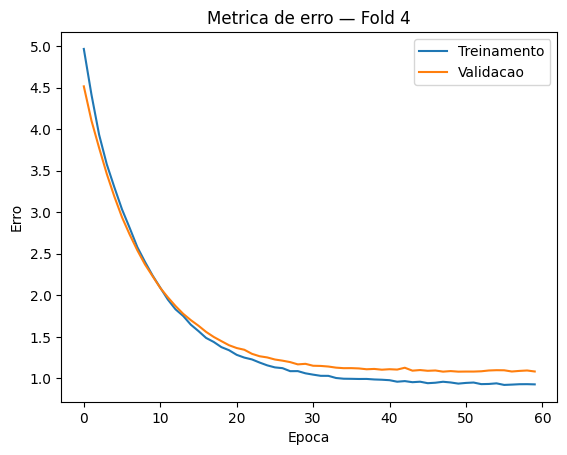

--> Acuracia (treino):    0.6409
--> Acuracia (validacao): 0.4413
--> E_val - E_in = 0.1710



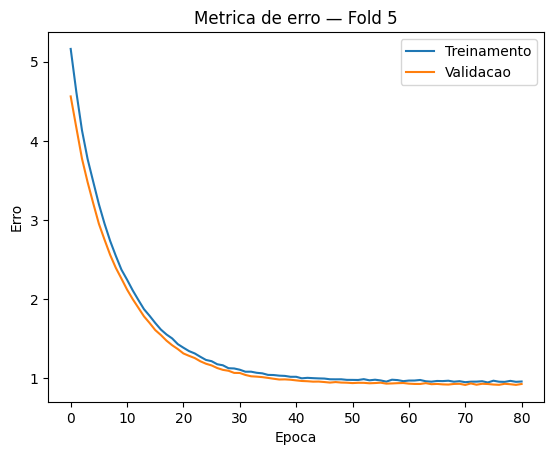

--> Acuracia (treino):    0.5906
--> Acuracia (validacao): 0.6197
--> E_val - E_in = -0.0150



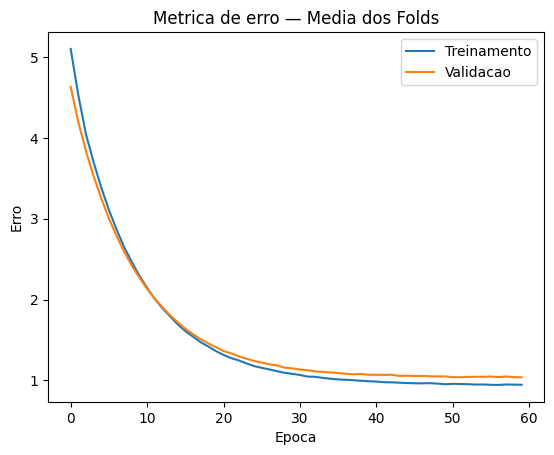

--> Acuracia media (treino):    0.6145
--> Acuracia media (validacao): 0.5346
--> E_in medio  = 0.9152
--> E_val medio = 1.0297
--> E_val - E_in = 0.1145


In [27]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

accuracies_train = []
accuracies_val   = []
history_list     = []
ein_list         = []
eval_list        = []

i = 0
for train_index, val_index in skf.split(X_train_scaled, y_train):
    i += 1
    X_train_fold = X_train_scaled[train_index]
    X_val_fold   = X_train_scaled[val_index]
    y_train_fold = y_train[train_index]
    y_val_fold   = y_train[val_index]

    model_fold = Sequential()
    model_fold.add(Input(shape=(13,)))
    model_fold.add(Dense(best_params_gs['neurons'], kernel_initializer='he_normal',
                         kernel_regularizer=regularizers.l2(best_params_gs['l2_reg']),
                         activation='relu'))
    if best_params_gs['dropout'] > 0:
        model_fold.add(Dropout(best_params_gs['dropout']))
    model_fold.add(Dense(best_params_gs['neurons'], kernel_initializer='he_normal',
                         kernel_regularizer=regularizers.l2(best_params_gs['l2_reg']),
                         activation='relu'))
    if best_params_gs['dropout'] > 0:
        model_fold.add(Dropout(best_params_gs['dropout']))
    model_fold.add(Dense(3, kernel_initializer='glorot_normal', activation='softmax'))
    model_fold.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    es_fold = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=0)
    history_fold = model_fold.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100, batch_size=BATCH_SIZE,
        callbacks=[es_fold], verbose=0
    )
    history_list.append(history_fold)

    E_in,  accuracy_train = model_fold.evaluate(X_train_fold, y_train_fold, verbose=0)
    E_val, accuracy_val   = model_fold.evaluate(X_val_fold,   y_val_fold,   verbose=0)
    accuracies_train.append(accuracy_train)
    accuracies_val.append(accuracy_val)
    ein_list.append(E_in)
    eval_list.append(E_val)

    plt.plot(history_fold.history['loss'])
    plt.plot(history_fold.history['val_loss'])
    plt.title(f'Metrica de erro — Fold {i}')
    plt.ylabel('Erro'); plt.xlabel('Epoca')
    plt.legend(['Treinamento', 'Validacao'])
    plt.show()

    print(f'--> Acuracia (treino):    {accuracy_train:.4f}')
    print(f'--> Acuracia (validacao): {accuracy_val:.4f}')
    print(f'--> E_val - E_in = {E_val - E_in:.4f}')
    print()

min_ep = min(len(h.history['loss']) for h in history_list)
history_loss_avg     = [np.mean([h.history['loss'][ep]     for h in history_list]) for ep in range(min_ep)]
history_val_loss_avg = [np.mean([h.history['val_loss'][ep] for h in history_list]) for ep in range(min_ep)]

plt.plot(history_loss_avg)
plt.plot(history_val_loss_avg)
plt.title('Metrica de erro — Media dos Folds')
plt.ylabel('Erro'); plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

avg_acc_train = np.mean(accuracies_train)
avg_acc_val   = np.mean(accuracies_val)
avg_ein       = np.mean(ein_list)
avg_eval      = np.mean(eval_list)

print(f'--> Acuracia media (treino):    {avg_acc_train:.4f}')
print(f'--> Acuracia media (validacao): {avg_acc_val:.4f}')
print(f'--> E_in medio  = {avg_ein:.4f}')
print(f'--> E_val medio = {avg_eval:.4f}')
print(f'--> E_val - E_in = {avg_eval - avg_ein:.4f}')


In [28]:
# Treinar modelo final com todos os dados de treino (melhores hiperparametros)
model_final = Sequential()
model_final.add(Input(shape=(13,)))
model_final.add(Dense(best_params_gs['neurons'], kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(best_params_gs['l2_reg']),
                      activation='relu'))
if best_params_gs['dropout'] > 0:
    model_final.add(Dropout(best_params_gs['dropout']))
model_final.add(Dense(best_params_gs['neurons'], kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(best_params_gs['l2_reg']),
                      activation='relu'))
if best_params_gs['dropout'] > 0:
    model_final.add(Dropout(best_params_gs['dropout']))
model_final.add(Dense(3, kernel_initializer='glorot_normal', activation='softmax'))
model_final.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

X_tr_f, X_vl_f, y_tr_f, y_vl_f = model_selection.train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=RANDOM_STATE
)
es_final = EarlyStopping(monitor='val_loss', patience=10,
                         restore_best_weights=True, verbose=0)
model_final.fit(X_tr_f, y_tr_f, validation_data=(X_vl_f, y_vl_f),
                epochs=100, batch_size=BATCH_SIZE, callbacks=[es_final], verbose=0)

E_in,  acc_nn_train = model_final.evaluate(X_train_scaled, y_train,    verbose=0)
E_out, acc_nn_test  = model_final.evaluate(X_test_scaled,  y_test,     verbose=0)
y_pred_nn = np.argmax(model_final.predict(X_test_scaled), axis=1)

print('Rede Neural — Modelo final:')
print(f'--> E_in  = {E_in:.4f}  (acuracia treino: {acc_nn_train:.4f})')
print(f'--> E_out = {E_out:.4f}  (acuracia teste:  {acc_nn_test:.4f})')
print(f'--> E_out - E_in = {E_out - E_in:.4f}')
print()
print(classification_report(y_test, y_pred_nn, target_names=['Baixa', 'Media', 'Alta']))



1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


Rede Neural — Modelo final:
--> E_in  = 0.9429  (acuracia treino: 0.5964)
--> E_out = 0.9736  (acuracia teste:  0.5896)
--> E_out - E_in = 0.0307

              precision    recall  f1-score   support

       Baixa       0.58      0.57      0.58        89
       Media       0.58      0.47      0.52        88
        Alta       0.61      0.73      0.66        91

    accuracy                           0.59       268
   macro avg       0.59      0.59      0.58       268
weighted avg       0.59      0.59      0.58       268



## 9. Comparação dos Modelos

### 9.1 Baseline — Classificador Aleatório Estratificado

Para confirmar que os modelos aprendem padrões reais, comparamos com um `DummyClassifier(strategy='stratified')`, que sorteia classes aleatoriamente respeitando a distribuição do conjunto de treino. Um modelo útil deve superar claramente esse baseline.

In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

# Baseline: classificador aleatório estratificado
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy  = f1_score(y_test, y_pred_dummy, average='macro')

# Scores dos modelos
y_pred_tree = best_tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree  = f1_score(y_test, y_pred_tree, average='macro')

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='macro')

y_pred_svm = best_svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='macro')

acc_nn = acc_nn_test
f1_nn  = f1_score(y_test, y_pred_nn, average='macro')

# Tabela comparativa
print(f'{"Modelo":<18} {"F1-macro":>10} {"Acurácia":>10}')
print('-' * 42)
for nome, f1, acc in [
    ('Dummy',          f1_dummy, acc_dummy),
    ('Árvore',         f1_tree,  acc_tree),
    ('Random Forest',  f1_rf,    acc_rf),
    ('SVM',            f1_svm,   acc_svm),
    ('Rede Neural',    f1_nn,    acc_nn),
]:
    print(f'{nome:<18} {f1:>10.4f} {acc:>10.4f}')

Modelo               F1-macro   Acurácia
------------------------------------------
Dummy                  0.3356     0.3358
Árvore                 0.5340     0.5373
Random Forest          0.6087     0.6082
SVM                    0.6128     0.6157
Rede Neural            0.5840     0.5896


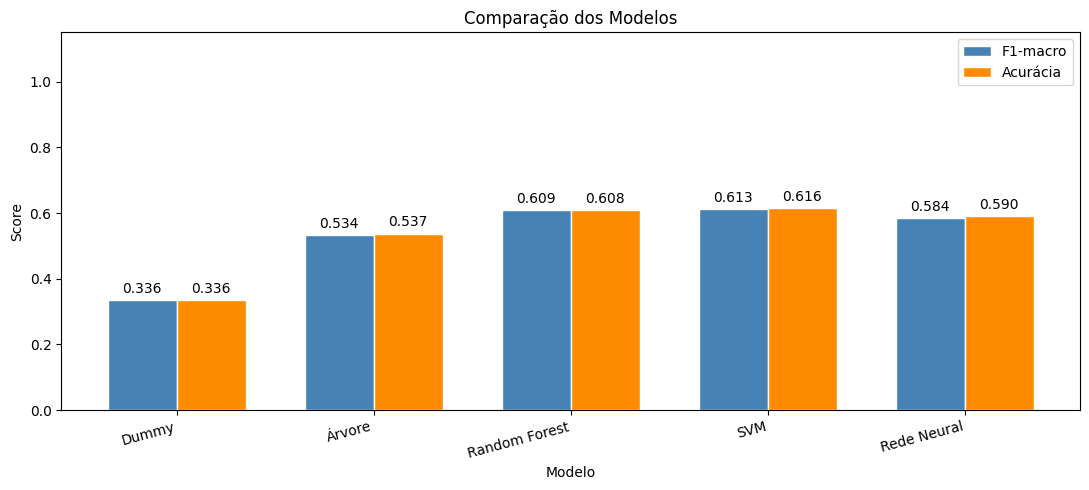

In [30]:
modelos    = ['Dummy', 'Árvore', 'Random Forest', 'SVM', 'Rede Neural']
f1_scores  = [f1_dummy, f1_tree, f1_rf,  f1_svm,  f1_nn]
acc_scores = [acc_dummy, acc_tree, acc_rf, acc_svm, acc_nn]

x     = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, f1_scores,  width, label='F1-macro', color='steelblue',  edgecolor='white')
bars2 = ax.bar(x + width/2, acc_scores, width, label='Acurácia', color='darkorange', edgecolor='white')

ax.set_xlabel('Modelo')
ax.set_ylabel('Score')
ax.set_title('Comparação dos Modelos')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
fig.tight_layout()
plt.show()

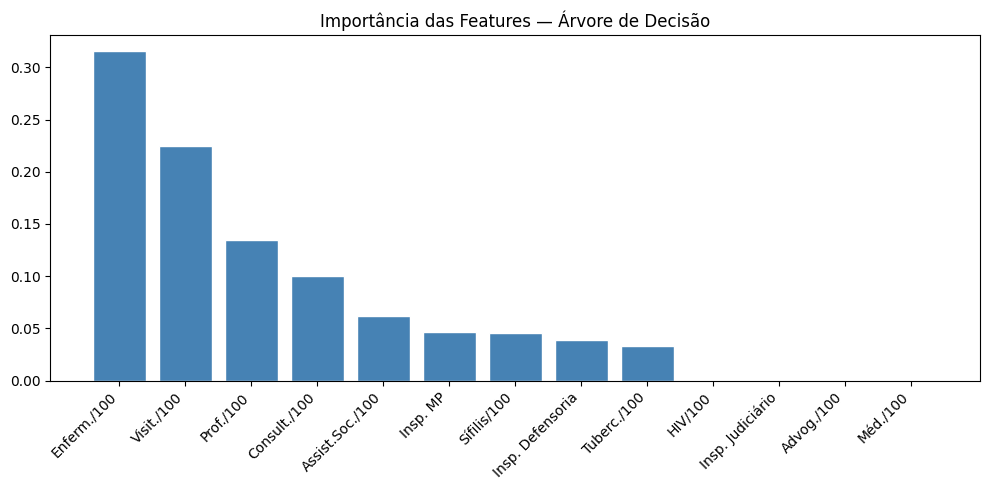


Ranking de importância:
  Enferm./100            0.3154
  Visit./100             0.2245
  Prof./100              0.1346
  Consult./100           0.1004
  Assist.Soc./100        0.0614
  Insp. MP               0.0465
  Sífilis/100            0.0452
  Insp. Defensoria       0.0386
  Tuberc./100            0.0334
  HIV/100                0.0000
  Insp. Judiciário       0.0000
  Advog./100             0.0000
  Méd./100               0.0000


In [31]:
# Importância das features da Árvore de Decisão
importances = best_tree.feature_importances_
feature_names_display = [
    'Assist.Soc./100', 'Méd./100', 'Enferm./100', 'Prof./100', 'Advog./100',
    'Insp. MP', 'Insp. Defensoria', 'Insp. Judiciário',
    'Visit./100', 'HIV/100', 'Tuberc./100', 'Sífilis/100', 'Consult./100'
]

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names_display)), importances[indices],
        color='steelblue', edgecolor='white')
plt.xticks(range(len(feature_names_display)),
           [feature_names_display[i] for i in indices],
           rotation=45, ha='right')
plt.title('Importância das Features — Árvore de Decisão')
plt.tight_layout()
plt.show()

print('\nRanking de importância:')
for i in indices:
    print(f'  {feature_names_display[i]:<22} {importances[i]:.4f}')